# RAF-DB Facial Emotion Recognition — Generalization & Deployment (DDAMFN)

Two questions a single test-set number cannot answer:

1. **Does the model generalize?** The RAF-DB-trained model is evaluated, with **no retraining**, on two datasets it
   has never seen: **FER2013** (48×48 grayscale web faces) and **CK+** (posed laboratory expressions).
2. **Can it be deployed efficiently?** The model is exported to **ONNX** and quantized to **INT8**. We measure size,
   CPU latency and accuracy on the RAF-DB test set.

**Inputs:** RAF-DB dataset, the trained checkpoint `ddamfn_rafdb_final.pth`, FER2013 and CK+ (48×48 folders by emotion).

## 0 · Model code

In [ ]:
%%writefile MixedFeatureNet.py

from torch.nn import Linear, Conv2d, BatchNorm1d, BatchNorm2d, PReLU, Sequential, Module
import torch
import torch.nn as nn
class Flatten(Module):
    def forward(self, input):
        return input.view(input.size(0), -1)

def l2_norm(input,axis=1):
    norm = torch.norm(input,2,axis,True)
    output = torch.div(input, norm)
    return output

class Conv_block(Module):
    def __init__(self, in_c, out_c, kernel=(1, 1), stride=(1, 1), padding=(0, 0), groups=1):
        super(Conv_block, self).__init__()
        self.conv = Conv2d(in_c, out_channels=out_c, kernel_size=kernel, groups=groups, stride=stride, padding=padding, bias=False)
        self.bn = BatchNorm2d(out_c)
        self.prelu = PReLU(out_c)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.prelu(x)
        return x

class Linear_block(Module):
    def __init__(self, in_c, out_c, kernel=(1, 1), stride=(1, 1), padding=(0, 0), groups=1):
        super(Linear_block, self).__init__()
        self.conv = Conv2d(in_c, out_channels=out_c, kernel_size=kernel, groups=groups, stride=stride, padding=padding, bias=False)
        self.bn = BatchNorm2d(out_c)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return x

class Depth_Wise(Module):
     def __init__(self, in_c, out_c, residual = False, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=1):
        super(Depth_Wise, self).__init__()
        self.conv = Conv_block(in_c, out_c=groups, kernel=(1, 1), padding=(0, 0), stride=(1, 1))
        self.conv_dw = Conv_block(groups, groups, groups=groups, kernel=kernel, padding=padding, stride=stride)
        self.project = Linear_block(groups, out_c, kernel=(1, 1), padding=(0, 0), stride=(1, 1))
        self.residual = residual
     def forward(self, x):
        if self.residual:
            short_cut = x
        x = self.conv(x)
        x = self.conv_dw(x)
        x = self.project(x)
        if self.residual:
            output = short_cut + x
        else:
            output = x
        return output
  

class Swish(nn.Module):
    def __init__(self):
        super(Swish, self).__init__()

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return x * self.sigmoid(x)

NON_LINEARITY = {
    'ReLU': nn.ReLU(inplace=True),
    'Swish': Swish(),
}        


class h_sigmoid(nn.Module):
    def __init__(self, inplace=True):
        super(h_sigmoid, self).__init__()
        self.relu = nn.ReLU6(inplace=inplace)

    def forward(self, x):
        return self.relu(x + 3) / 6

class h_swish(nn.Module):
    def __init__(self, inplace=True):
        super(h_swish, self).__init__()
        self.sigmoid = h_sigmoid(inplace=inplace)

    def forward(self, x):
        return x * self.sigmoid(x)

class swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)
    
class CoordAtt(nn.Module):
    def __init__(self, inp, oup, groups=32):
        super(CoordAtt, self).__init__()
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))

        mip = max(8, inp // groups)

        self.conv1 = nn.Conv2d(inp, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mip)
        self.conv2 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.conv3 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.relu = h_swish()

    def forward(self, x):
        identity = x
        n,c,h,w = x.size()
        x_h = self.pool_h(x)
        x_w = self.pool_w(x).permute(0, 1, 3, 2)

        y = torch.cat([x_h, x_w], dim=2)
        y = self.conv1(y)
        y = self.bn1(y)
        y = self.relu(y) 
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)

        x_h = self.conv2(x_h).sigmoid()
        x_w = self.conv3(x_w).sigmoid()
        x_h = x_h.expand(-1, -1, h, w)
        x_w = x_w.expand(-1, -1, h, w)

        y = identity * x_w * x_h

        return y

        
class MDConv(Module):
    def __init__(self, channels, kernel_size, split_out_channels, stride):
        super(MDConv, self).__init__()
        self.num_groups = len(kernel_size)
        self.split_channels = split_out_channels
        self.mixed_depthwise_conv = nn.ModuleList()
        for i in range(self.num_groups):
            self.mixed_depthwise_conv.append(Conv2d(
                self.split_channels[i],
                self.split_channels[i],
                kernel_size[i],
                stride=stride,
                padding=kernel_size[i]//2,
                groups=self.split_channels[i],
                bias=False
            ))
        self.bn = BatchNorm2d(channels)
        self.prelu = PReLU(channels)            
       
    def forward(self, x):
        if self.num_groups == 1:
            return self.mixed_depthwise_conv[0](x)

        x_split = torch.split(x, self.split_channels, dim=1)
        x = [conv(t) for conv, t in zip(self.mixed_depthwise_conv, x_split)]
        x = torch.cat(x, dim=1)

        return x        
      
        
class Mix_Depth_Wise(Module):
     def __init__(self, in_c, out_c, residual = False, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=1, kernel_size=[3,5,7], split_out_channels=[64,32,32]):
        super(Mix_Depth_Wise, self).__init__()
        self.conv = Conv_block(in_c, out_c=groups, kernel=(1, 1), padding=(0, 0), stride=(1, 1))
        self.conv_dw = MDConv(channels=groups, kernel_size=kernel_size, split_out_channels=split_out_channels, stride=stride)
        self.CA = CoordAtt(groups, groups)
        self.project = Linear_block(groups, out_c, kernel=(1, 1), padding=(0, 0), stride=(1, 1))
        self.residual = residual
     def forward(self, x):
        if self.residual:
            short_cut = x
        x = self.conv(x)
        x = self.conv_dw(x)
        x = self.CA(x)
        x = self.project(x)
        if self.residual:
            output = short_cut + x
        else:
            output = x
        return output
          
class Residual(Module):
    def __init__(self, c, num_block, groups, kernel=(3, 3), stride=(1, 1), padding=(1, 1)):
        super(Residual, self).__init__()
        modules = []
        for _ in range(num_block):
            modules.append(Depth_Wise(c, c, residual=True, kernel=kernel, padding=padding, stride=stride, groups=groups))
        self.model = Sequential(*modules)
    def forward(self, x):
        return self.model(x)
        
class Mix_Residual(Module):
    def __init__(self, c, num_block, groups, kernel=(3, 3), stride=(1, 1), padding=(1, 1), kernel_size=[3,5], split_out_channels=[64,64]):
        super(Mix_Residual, self).__init__()
        modules = []
        for _ in range(num_block):
            modules.append(Mix_Depth_Wise(c, c, residual=True, kernel=kernel, padding=padding, stride=stride, groups=groups, kernel_size=kernel_size, split_out_channels=split_out_channels ))
        self.model = Sequential(*modules)
    def forward(self, x):
        return self.model(x)
        

class MixedFeatureNet(Module):
    def __init__(self, embedding_size=256, out_h=7, out_w=7):
        super(MixedFeatureNet, self).__init__()
        #112x112
        self.conv1 = Conv_block(3, 64, kernel=(3, 3), stride=(2, 2), padding=(1, 1))
        #56x56
        self.conv2_dw = Conv_block(64, 64, kernel=(3, 3), stride=(1, 1), padding=(1, 1), groups=64)
        self.conv_23 = Mix_Depth_Wise(64, 64, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=128, kernel_size=[3,5,7], split_out_channels=[64,32,32] )
        
        #28x28
        self.conv_3 = Mix_Residual(64, num_block=9, groups=128, kernel=(3, 3), stride=(1, 1), padding=(1, 1), kernel_size=[3,5], split_out_channels=[96,32])
        self.conv_34 = Mix_Depth_Wise(64, 128, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=256, kernel_size=[3,5,7],split_out_channels=[128,64,64] )
        
        #14x14
        self.conv_4 = Mix_Residual(128, num_block=16, groups=256, kernel=(3, 3), stride=(1, 1), padding=(1, 1), kernel_size=[3,5], split_out_channels=[192,64])
        self.conv_45 = Mix_Depth_Wise(128, 256, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=512*2, kernel_size=[3,5,7,9],split_out_channels=[128*2,128*2,128*2,128*2] )
        #7x7
        self.conv_5 = Mix_Residual(256, num_block=6, groups=512, kernel=(3, 3), stride=(1, 1), padding=(1, 1), kernel_size=[3,5,7], split_out_channels=[86*2,85*2,85*2])                
        self.conv_6_sep = Conv_block(256, 512, kernel=(1, 1), stride=(1, 1), padding=(0, 0))
        self.conv_6_dw = Linear_block(512, 512, groups=512, kernel=(out_h, out_w), stride=(1, 1), padding=(0, 0))
        self.conv_6_flatten = Flatten()
        self.linear = Linear(512, embedding_size, bias=False)
        self.bn = BatchNorm1d(embedding_size)
    
    def forward(self, x):
        out = self.conv1(x)
        out = self.conv2_dw(out)
        out = self.conv_23(out)
        out = self.conv_3(out)
        out = self.conv_34(out)
        out = self.conv_4(out)
        out = self.conv_45(out)
        out = self.conv_5(out)
        out = self.conv_6_sep(out)
        out = self.conv_6_dw(out)
        out = self.conv_6_flatten(out)
        out = self.linear(out)
        out = self.bn(out)

        return l2_norm(out)

Writing MixedFeatureNet.py


In [ ]:
%%writefile DDAM.py
from torch import nn
import torch
import MixedFeatureNet
from torch.nn import Module
import os
class Linear_block(Module):
    def __init__(self, in_c, out_c, kernel=(1, 1), stride=(1, 1), padding=(0, 0), groups=1):
        super(Linear_block, self).__init__()
        self.conv = nn.Conv2d(in_c, out_channels=out_c, kernel_size=kernel, groups=groups, stride=stride, padding=padding, bias=False)
        self.bn = nn.BatchNorm2d(out_c)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return x

class Flatten(Module):
    def forward(self, input):
        return input.view(input.size(0), -1)
        
class DDAMNet(nn.Module):
    def __init__(self, num_class=7,num_head=2, pretrained=True):
        super(DDAMNet, self).__init__()

        net = MixedFeatureNet.MixedFeatureNet()
                
        if pretrained:
            net = torch.load(os.path.join('./pretrained/', "MFN_msceleb.pth"))       
      
        self.features = nn.Sequential(*list(net.children())[:-4])
        self.num_head = num_head
        for i in range(int(num_head)):
            setattr(self,"cat_head%d" %(i), CoordAttHead())                  
      
        self.Linear = Linear_block(512, 512, groups=512, kernel=(7, 7), stride=(1, 1), padding=(0, 0))
        self.flatten = Flatten()      
        self.fc = nn.Linear(512, num_class)
        self.bn = nn.BatchNorm1d(num_class)
        
    def forward(self, x):
        x = self.features(x)
        heads = []
       
        for i in range(self.num_head):
            heads.append(getattr(self,"cat_head%d" %i)(x))
        head_out =heads
        
        y = heads[0]
        
        for i in range(1,self.num_head):
            y = torch.max(y,heads[i])                     
        
        y = x*y
        y = self.Linear(y)
        y = self.flatten(y) 
        out = self.fc(y)        
        return out, x, head_out
        
class h_sigmoid(nn.Module):
    def __init__(self, inplace=True):
        super(h_sigmoid, self).__init__()
        self.relu = nn.ReLU6(inplace=inplace)
    def forward(self, x):
        return self.relu(x + 3) / 6
                      
class h_swish(nn.Module):
    def __init__(self, inplace=True):
        super(h_swish, self).__init__()
        self.sigmoid = h_sigmoid(inplace=inplace)
    def forward(self, x):
        return x * self.sigmoid(x)

class CoordAttHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.CoordAtt = CoordAtt(512,512)
    def forward(self, x):
        ca = self.CoordAtt(x)
        return ca  
        
class CoordAtt(nn.Module):
    def __init__(self, inp, oup, groups=32):
        super(CoordAtt, self).__init__()
      
        self.Linear_h = Linear_block(inp, inp, groups=inp, kernel=(1, 7), stride=(1, 1), padding=(0, 0))        
        self.Linear_w = Linear_block(inp, inp, groups=inp, kernel=(7, 1), stride=(1, 1), padding=(0, 0))
        
        mip = max(8, inp // groups)

        self.conv1 = nn.Conv2d(inp, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mip)
        self.conv2 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.conv3 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.relu = h_swish()
        self.Linear = Linear_block(oup, oup, groups=oup, kernel=(7, 7), stride=(1, 1), padding=(0, 0))
        self.flatten = Flatten() 

    def forward(self, x):
        identity = x
        n,c,h,w = x.size()
        x_h = self.Linear_h(x)
        x_w = self.Linear_w(x)
        x_w = x_w.permute(0, 1, 3, 2)

        y = torch.cat([x_h, x_w], dim=2)
        y = self.conv1(y)
        y = self.bn1(y)
        y = self.relu(y) 
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)

        x_h = self.conv2(x_h).sigmoid()
        x_w = self.conv3(x_w).sigmoid()
        x_h = x_h.expand(-1, -1, h, w)
        x_w = x_w.expand(-1, -1, h, w)
        
        y = x_w * x_h
 
        return y

Writing DDAM.py


## 1 · Setup

In [ ]:
import os, sys, json, time, random, numpy as np, pandas as pd, torch, torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
sys.path.insert(0, os.getcwd())
from DDAM import DDAMNet

SEED = 42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DATA = os.environ.get('DATA_ROOT', '/kaggle/input')
OUT  = os.environ.get('OUT_ROOT', '/kaggle/working')
FIG  = os.path.join(OUT, 'figs'); os.makedirs(FIG, exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
S = 112
CLASS_NAMES = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
EMO_HEX = {'Happiness': '#22c55e', 'Surprise': '#06b6d4', 'Neutral': '#94a3b8', 'Sadness': '#3b82f6',
           'Fear': '#a855f7', 'Disgust': '#eab308', 'Anger': '#ef4444'}
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titleweight': 'bold'})
def save(fig, name):
    fig.savefig(os.path.join(FIG, name), bbox_inches='tight', facecolor='white'); plt.show()

# folder names used by FER2013 / CK+ -> our label space
FOLDER2EMO = {'angry': 'Anger', 'anger': 'Anger', 'disgust': 'Disgust', 'fear': 'Fear', 'happy': 'Happiness',
              'happiness': 'Happiness', 'neutral': 'Neutral', 'sad': 'Sadness', 'sadness': 'Sadness',
              'surprise': 'Surprise'}

train_csv = test_csv = ckpt_path = None; IMG = {}; FER, CK = [], []
for root, _, files in os.walk(DATA):
    low = root.lower().replace('\\', '/'); parent = os.path.basename(root).lower()
    for f in files:
        p = os.path.join(root, f)
        if   f == 'train_labels.csv': train_csv = p
        elif f == 'test_labels.csv':  test_csv = p
        elif f in ('ddamfn_rafdb_final.pth', 'ddamfn_rafdb_best.pth'): ckpt_path = p
        elif f.lower().endswith(('.jpg', '.jpeg', '.png')):
            if parent in FOLDER2EMO and 'fer' in low and '/test' in low:
                FER.append((p, CLASS_NAMES.index(FOLDER2EMO[parent])))
            elif parent in FOLDER2EMO and 'ck' in low:
                CK.append((p, CLASS_NAMES.index(FOLDER2EMO[parent])))
            else:
                IMG[f] = p
def dedup(items):  # some Kaggle datasets ship the same images in two folders -> keep one copy per (emotion, file)
    seen, out = set(), []
    for p, y in items:
        k = (y, os.path.basename(p))
        if k not in seen: seen.add(k); out.append((p, y))
    return out
FER, CK = dedup(FER), dedup(CK)
assert train_csv and test_csv and ckpt_path, 'need the RAF-DB dataset and the checkpoint as inputs'
print(f'RAF-DB images {len(IMG)} | FER2013 test {len(FER)} | CK+ {len(CK)} | device {DEVICE}')

model = DDAMNet(num_class=7, num_head=2, pretrained=False).to(DEVICE).eval()
ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ck.get('model_state_dict', ck))

def load_paths(paths):
    return np.stack([np.array(Image.open(p).convert('RGB').resize((S, S), Image.BILINEAR)) for p in paths])

test_df = pd.read_csv(test_csv); train_full = pd.read_csv(train_csv)
_, val_df = train_test_split(train_full, test_size=0.10, stratify=train_full['label'], random_state=SEED)
Xte = load_paths([IMG[n] for n in test_df['image']]); yte = test_df['label'].to_numpy() - 1
Xva = load_paths([IMG[n] for n in val_df['image']])

MEAN = np.array([0.485, 0.456, 0.406], np.float32).reshape(1, 3, 1, 1)
STD  = np.array([0.229, 0.224, 0.225], np.float32).reshape(1, 3, 1, 1)
def prep(X):  # uint8 NHWC -> normalized float32 NCHW
    return ((X.transpose(0, 3, 1, 2).astype(np.float32) / 255) - MEAN) / STD

@torch.no_grad()
def predict_torch(X, bs=256):
    return np.concatenate([model(torch.from_numpy(prep(X[i:i + bs])).to(DEVICE))[0].cpu().numpy()
                           for i in range(0, len(X), bs)])

def scores(logits, y):
    p = logits.argmax(1); return 100 * (p == y).mean(), 100 * balanced_accuracy_score(y, p)

raf_acc, raf_bacc = scores(predict_torch(Xte), yte)
print(f'RAF-DB test (in-domain): overall {raf_acc:.2f}% | mean-class {raf_bacc:.2f}%')

RAF-DB test (in-domain): overall 91.07% | mean-class 84.64%


## 2 · Cross-dataset generalization (no retraining)
* **FER2013** — 48×48 grayscale internet faces with noisy labels; a much harder, lower-quality domain.
* **CK+** — posed, exaggerated expressions filmed in a lab (the *contempt* class is excluded; no *neutral* class).

FER2013 (test)  n= 7178 | overall  55.29% | mean-class  50.89% | Surp  78.1 Fear  14.6 Disg  40.5 Happ  84.9 Sadn  49.2 Ange  32.9 Neut  56.0
CK+             | overall  77.02% | mean-class  69.16% | Surp  93.6 Fear  32.0 Disg  92.1 Happ 100.0 Sadn  86.9 Ange  10.4


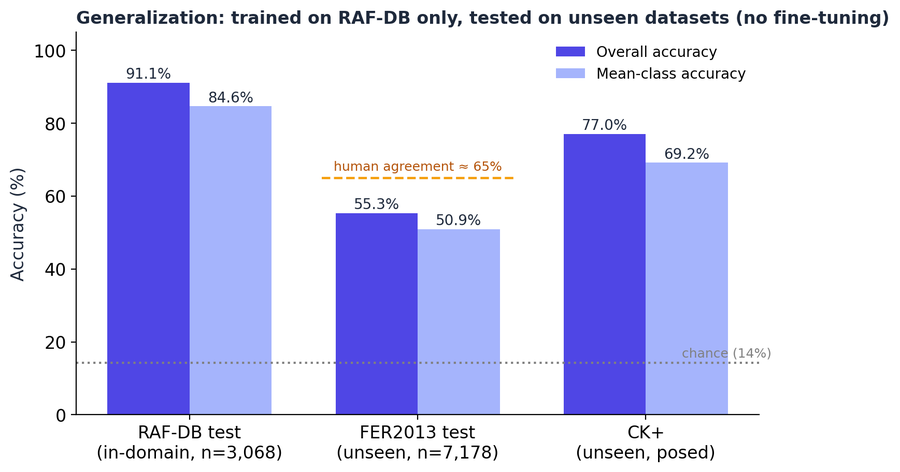

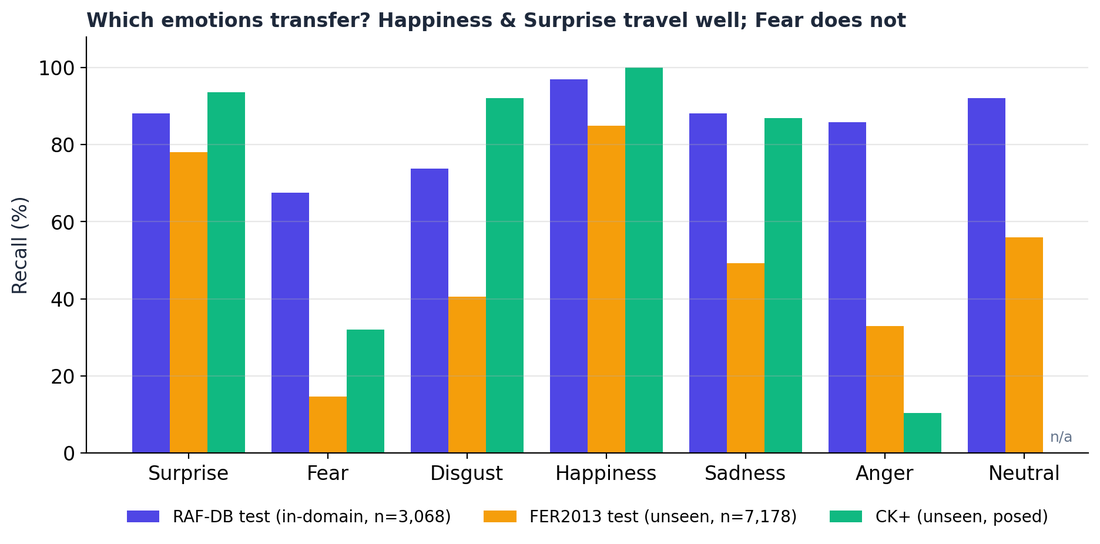

In [ ]:
cross = {}
for name, items in [('FER2013 (test)', FER), ('CK+', CK)]:
    if not items:
        print(f'{name}: not attached - skipped'); continue
    paths, y = zip(*items); y = np.array(y); X = load_paths(paths)
    logits = predict_torch(X); a, b = scores(logits, y); p = logits.argmax(1)
    present = sorted(set(y.tolist()))
    rec = {CLASS_NAMES[c]: round(100 * (p[y == c] == c).mean(), 1) for c in present}
    cross[name] = {'n': int(len(y)), 'overall': round(a, 2), 'mean_class': round(b, 2), 'recall': rec,
                   'cm': confusion_matrix(y, p, labels=list(range(7))).tolist()}
    print(f'{name:15s} n={len(y):5d} | overall {a:6.2f}% | mean-class {b:6.2f}% | ' + ' '.join(f'{k[:4]} {v:5.1f}' for k, v in rec.items()))

if cross:
    names = ['RAF-DB (in-domain)'] + list(cross)
    accs = [raf_acc] + [cross[n]['overall'] for n in cross]; baccs = [raf_bacc] + [cross[n]['mean_class'] for n in cross]
    fig, ax = plt.subplots(figsize=(8, 4.6)); x = np.arange(len(names)); w = .36
    b1 = ax.bar(x - w / 2, accs, w, color='#4f46e5', label='overall accuracy')
    b2 = ax.bar(x + w / 2, baccs, w, color='#a5b4fc', label='mean-class accuracy')
    for bars in (b1, b2):
        for r in bars: ax.text(r.get_x() + r.get_width() / 2, r.get_height() + 1, f'{r.get_height():.1f}', ha='center', fontsize=10)
    ax.axhline(100 / 7, ls=':', color='grey'); ax.text(len(names) - .5, 100 / 7 + 1.5, 'chance', ha='right', color='grey', fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylim(0, 105); ax.set_ylabel('Accuracy (%)'); ax.legend(frameon=False, loc='upper right')
    ax.set_title('Cross-dataset generalization — trained on RAF-DB only, no fine-tuning'); save(fig, 'cross_dataset.png')

    # per-class recall across domains
    fig, ax = plt.subplots(figsize=(10, 4.4)); ds = list(cross); w = .8 / (len(ds) + 1); xs = np.arange(7)
    raf_p = predict_torch(Xte).argmax(1); raf_rec = [100 * (raf_p[yte == c] == c).mean() for c in range(7)]
    ax.bar(xs - .4 + w / 2, raf_rec, w, color='#4f46e5', label='RAF-DB')
    for k, (n, col) in enumerate(zip(ds, ['#f59e0b', '#10b981'])):
        ax.bar(xs - .4 + w / 2 + (k + 1) * w, [cross[n]['recall'].get(c, np.nan) for c in CLASS_NAMES], w, color=col, label=n)
    ax.set_xticks(xs); ax.set_xticklabels(CLASS_NAMES); ax.set_ylabel('Recall (%)'); ax.set_ylim(0, 105); ax.grid(axis='y', alpha=.3)
    ax.legend(frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(.5, -.1)); ax.set_title('Per-emotion recall by dataset')
    save(fig, 'cross_dataset_per_class.png')

## 3 · Deployment — ONNX export and INT8 quantization
The PyTorch model is exported to ONNX and statically quantized to INT8 (QDQ, per-channel). Calibration uses
**300 validation images**, never the test set. All variants are scored on the same 3,068 RAF-DB test images.

In [ ]:
import subprocess
try:
    import onnx, onnxruntime as ort
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'onnx', 'onnxruntime'], check=False)
    import onnx, onnxruntime as ort
from onnxruntime.quantization import quantize_static, CalibrationDataReader, QuantFormat, QuantType
from onnxruntime.quantization.shape_inference import quant_pre_process

class LogitsOnly(torch.nn.Module):
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, x): return self.m(x)[0]

ref = predict_torch(Xte)   # reference logits on the original device, before moving the model to CPU
cpu_model = LogitsOnly(model.to('cpu')).eval()   # wrapper must be eval too: export restores the wrapper's mode recursively
FP32, PRE, INT8 = [os.path.join(OUT, f) for f in ('ddamfn_fp32.onnx', 'ddamfn_pre.onnx', 'ddamfn_int8.onnx')]
# static batch-1 graph: the model's CoordAtt splits on runtime H/W, which breaks dynamic-shape export
export_kw = dict(input_names=['input'], output_names=['logits'], opset_version=17)
try:
    torch.onnx.export(cpu_model, torch.randn(1, 3, S, S), FP32, dynamo=False, **export_kw)
except TypeError:
    torch.onnx.export(cpu_model, torch.randn(1, 3, S, S), FP32, **export_kw)
onnx.checker.check_model(FP32)
try:
    quant_pre_process(FP32, PRE); src = PRE
except Exception as e:
    print('pre-process skipped:', e); src = FP32

class ValReader(CalibrationDataReader):
    def __init__(self, X): self.batches = iter([prep(X[i:i + 1]) for i in range(len(X))])
    def get_next(self):
        b = next(self.batches, None); return None if b is None else {'input': b}
calib = Xva[np.random.default_rng(0).choice(len(Xva), min(300, len(Xva)), replace=False)]
quantize_static(src, INT8, ValReader(calib), quant_format=QuantFormat.QDQ, per_channel=True,
                activation_type=QuantType.QUInt8, weight_type=QuantType.QInt8)

so = ort.SessionOptions(); so.intra_op_num_threads = 2   # 2 threads ~ a free-tier CPU server
sess = {k: ort.InferenceSession(p, so, providers=['CPUExecutionProvider']) for k, p in [('ONNX FP32', FP32), ('ONNX INT8', INT8)]}
def predict_ort(s, X):
    return np.concatenate([s.run(None, {'input': prep(X[i:i + 1])})[0] for i in range(len(X))])

torch.set_num_threads(2)
def latency(fn, n=60):
    x = Xte[:1]; [fn(x) for _ in range(8)]; ts = []
    for _ in range(n):
        t = time.perf_counter(); fn(x); ts.append(1000 * (time.perf_counter() - t))
    return float(np.median(ts))

@torch.no_grad()
def torch_cpu(X): return cpu_model(torch.from_numpy(prep(X))).numpy()

deploy = {}
rows = [('PyTorch FP32', torch_cpu, None), ('ONNX FP32', None, 'ONNX FP32'), ('ONNX INT8', None, 'ONNX INT8')]
for name, tfn, sk in rows:
    fn = tfn if tfn else (lambda X, s=sess[sk]: s.run(None, {'input': prep(X)})[0])
    logits = ref if tfn else predict_ort(sess[sk], Xte)
    a, b = scores(logits, yte)
    size = os.path.getsize(ckpt_path) if tfn else os.path.getsize(FP32 if sk == 'ONNX FP32' else INT8)
    agree = 100 * (logits.argmax(1) == ref.argmax(1)).mean()
    deploy[name] = {'overall': round(a, 2), 'mean_class': round(b, 2), 'size_mb': round(size / 1e6, 2),
                    'cpu_ms_bs1': round(latency(fn), 1), 'agreement_with_fp32_pct': round(agree, 2)}
    print(f"{name:13s} acc {a:6.2f}% | mean-class {b:6.2f}% | {size / 1e6:5.1f} MB | {deploy[name]['cpu_ms_bs1']:6.1f} ms (2 CPU threads) | agrees with PyTorch on {agree:.2f}% of images")
model.to(DEVICE)

names = list(deploy); col = ['#94a3b8', '#6366f1', '#4f46e5']
fig, axs = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True, gridspec_kw={'wspace': 0.35})
for a, key, lab, fmt in [(axs[0], 'cpu_ms_bs1', 'CPU latency per face (ms) - lower is better', '{:.1f} ms'),
                         (axs[1], 'size_mb', 'Model file size (MB) - lower is better', '{:.1f} MB'),
                         (axs[2], 'overall', 'RAF-DB test accuracy (%)', '{:.2f}%')]:
    v = [deploy[n][key] for n in names]; bars = a.barh(names, v, color=col)
    for r, val in zip(bars, v): a.text(r.get_width(), r.get_y() + r.get_height() / 2, ' ' + fmt.format(val), va='center', fontsize=10)
    a.set_title(lab, fontsize=11); a.set_xlim(0, max(v) * 1.45 if key != 'overall' else 112)
axs[0].invert_yaxis()
fig.suptitle('Deployment: ONNX + INT8 quantization (2 CPU threads, batch 1)', fontweight='bold', y=1.04); save(fig, 'deployment_onnx_int8.png')

## 4 · Summary

In [ ]:
summary = {'raf_db': {'overall': round(raf_acc, 2), 'mean_class': round(raf_bacc, 2)},
           'cross_dataset': {k: {kk: vv for kk, vv in v.items() if kk != 'cm'} for k, v in cross.items()},
           'deployment': deploy}
json.dump(summary, open(os.path.join(OUT, 'generalization_results.json'), 'w'), indent=2)
print(json.dumps(summary, indent=2))
import shutil; shutil.make_archive(os.path.join(OUT, 'generalization_figures'), 'zip', FIG); print(sorted(os.listdir(FIG)))